In [1]:
import os
import pandas as pd
import numpy as np
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report

PROJECT_ROOT = "/Users/dwibon/Desktop/IKS-Internship"
os.chdir(PROJECT_ROOT)

FEATURES_PATH = "dataset_segments/segment_features.csv"
RANDOM_STATE = 42

In [2]:
df = pd.read_csv(FEATURES_PATH)

print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nGenre distribution:\n", df["genre"].value_counts())
print("\nSegments per singer (top 10):\n", df["singer"].value_counts().head(10))
df.head()

Shape: (3088, 79)

Columns: ['Recoding ID', 'genre', 'subgenre', 'Song Title', 'singer', 'Gender', 'YouTube URL', 'duration_sec', 'segment_id', 'recording_id', 'segment_index', 'segment_start_sec', 'segment_end_sec', 'segment_duration_sec', 'edge_trimmed', 'rms_energy', 'likely_silent', 'segment_filepath', 'time_rms_mean', 'time_rms_std', 'time_zcr_mean', 'time_zcr_std', 'spectral_centroid_mean', 'spectral_centroid_std', 'spectral_rolloff_mean', 'spectral_rolloff_std', 'spectral_bandwidth_mean', 'spectral_bandwidth_std', 'mfcc_1_mean', 'mfcc_1_std', 'mfcc_2_mean', 'mfcc_2_std', 'mfcc_3_mean', 'mfcc_3_std', 'mfcc_4_mean', 'mfcc_4_std', 'mfcc_5_mean', 'mfcc_5_std', 'mfcc_6_mean', 'mfcc_6_std', 'mfcc_7_mean', 'mfcc_7_std', 'mfcc_8_mean', 'mfcc_8_std', 'mfcc_9_mean', 'mfcc_9_std', 'mfcc_10_mean', 'mfcc_10_std', 'mfcc_11_mean', 'mfcc_11_std', 'mfcc_12_mean', 'mfcc_12_std', 'mfcc_13_mean', 'mfcc_13_std', 'chroma_1_mean', 'chroma_1_std', 'chroma_2_mean', 'chroma_2_std', 'chroma_3_mean', 'chro

,Recoding ID,genre,subgenre,Song Title,singer,Gender,YouTube URL,duration_sec,segment_id,recording_id,...,chroma_8_std,chroma_9_mean,chroma_9_std,chroma_10_mean,chroma_10_std,chroma_11_mean,chroma_11_std,chroma_12_mean,chroma_12_std,tempo_bpm
0,AFM0001.wav,Kamrupi,NaN,Pokhi Roya Ja Re,Rameshwar Pathak,M,https://youtu.be/dU8AHeKOUQE?si=y9zCEIdga78WbKFz,261.0,AFM0001_seg00,AFM0001.wav,...,0.439755,0.166030,0.170797,0.332119,0.421232,0.082138,0.122629,0.023384,0.042176,117.453835
1,AFM0001.wav,Kamrupi,NaN,Pokhi Roya Ja Re,Rameshwar Pathak,M,https://youtu.be/dU8AHeKOUQE?si=y9zCEIdga78WbKFz,261.0,AFM0001_seg01,AFM0001.wav,...,0.447027,0.117371,0.161500,0.113279,0.226125,0.034327,0.102987,0.028805,0.066027,143.554688
2,AFM0001.wav,Kamrupi,NaN,Pokhi Roya Ja Re,Rameshwar Pathak,M,https://youtu.be/dU8AHeKOUQE?si=y9zCEIdga78WbKFz,261.0,AFM0001_seg02,AFM0001.wav,...,0.419215,0.248990,0.288506,0.360282,0.420630,0.097940,0.156430,0.028626,0.063558,92.285156
3,AFM0001.wav,Kamrupi,NaN,Pokhi Roya Ja Re,Rameshwar Pathak,M,https://youtu.be/dU8AHeKOUQE?si=y9zCEIdga78WbKFz,261.0,AFM0001_seg03,AFM0001.wav,...,0.380009,0.229324,0.273638,0.478196,0.442659,0.340631,0.362398,0.093773,0.188723,129.199219
4,AFM0001.wav,Kamrupi,NaN,Pokhi Roya Ja Re,Rameshwar Pathak,M,https://youtu.be/dU8AHeKOUQE?si=y9zCEIdga78WbKFz,261.0,AFM0001_seg04,AFM0001.wav,...,0.372806,0.248047,0.274497,0.391146,0.383597,0.256250,0.290637,0.143844,0.228356,92.285156


In [3]:
GROUP_PREFIXES = {
    "time": "time_",
    "spectral": "spectral_",
    "mfcc": "mfcc_",
    "chroma": "chroma_",
    "tempo": "tempo_",
}

# CHANGE THIS to test a different group - rerun from here down
FEATURE_GROUPS_TO_TEST = ["tempo"]

def select_feature_columns(df, groups):
    cols = []
    for g in groups:
        prefix = GROUP_PREFIXES[g]
        cols.extend([c for c in df.columns if c.startswith(prefix)])
    if not cols:
        raise ValueError(f"No columns found for groups {groups}")
    return cols

cols = select_feature_columns(df, FEATURE_GROUPS_TO_TEST)
print(f"Testing: {FEATURE_GROUPS_TO_TEST}  ({len(cols)} features)")
print(cols)

X = df[cols].values
y = df["genre"].values
singers = df["singer"].values

Testing: ['tempo']  (1 features)
['tempo_bpm']


In [4]:
def loso_per_singer(X, y, singers, model, model_name):
    unique_singers = np.unique(singers)
    scaler = StandardScaler()
    results = []

    for singer in unique_singers:
        test_mask = singers == singer
        train_mask = ~test_mask
        if test_mask.sum() == 0 or train_mask.sum() == 0:
            continue

        X_train = scaler.fit_transform(X[train_mask])
        X_test = scaler.transform(X[test_mask])

        model.fit(X_train, y[train_mask])
        preds = model.predict(X_test)
        acc = accuracy_score(y[test_mask], preds)

        results.append({
            "singer": singer,
            "n_segments": test_mask.sum(),
            "accuracy": round(acc, 3),
            "genre": y[test_mask][0],  # each singer's segments share one genre
        })

    return pd.DataFrame(results).sort_values("n_segments", ascending=False)

svm = SVC(kernel="rbf", C=1.0, gamma="scale", random_state=RANDOM_STATE)
per_singer_df = loso_per_singer(X, y, singers, svm, "SVM")
per_singer_df

,singer,n_segments,accuracy,genre
18,Pratima Pandey Barua,603,0.317,Goalpariya
23,Rameshwar Pathak,483,0.516,Kamrupi
0,Abdul Jabbar,343,0.860,Goalpariya
31,Zubeen Garg,186,0.704,Kamrupi
13,Manik Ali,129,0.752,Goalpariya
16,Parag Talukdar,127,0.717,Kamrupi
17,Pranita Baishya,124,0.992,Kamrupi
5,Archana Baruah,106,0.698,Kamrupi
11,Jumi Das,93,0.978,Kamrupi
8,Bina sharma,88,0.841,Kamrupi


In [5]:
MIN_SEGMENTS = 10  # adjust based on your actual segment counts per singer

reliable = per_singer_df[per_singer_df["n_segments"] >= MIN_SEGMENTS].copy()

print(f"Singers with >= {MIN_SEGMENTS} segments: {len(reliable)} of {len(per_singer_df)} total\n")
print("Sorted worst to best (these are the ones that matter most):")
reliable.sort_values("accuracy")

Singers with >= 10 segments: 32 of 32 total

Sorted worst to best (these are the ones that matter most):


,singer,n_segments,accuracy,genre
4,Anita Saha,26,0.038,Goalpariya
3,Akshay Barman,34,0.088,Kamrupi
18,Pratima Pandey Barua,603,0.317,Goalpariya
24,"Rameshwar Pathak, Dhanada Pathak",28,0.357,Kamrupi
6,Bina Das Borthakur,22,0.455,Goalpariya
23,Rameshwar Pathak,483,0.516,Kamrupi
1,Abdul Jabbar and group,42,0.548,Goalpariya
10,Dhanmoni Saikia,26,0.615,Kamrupi
9,Dhanada Pathak,38,0.632,Kamrupi
5,Archana Baruah,106,0.698,Kamrupi


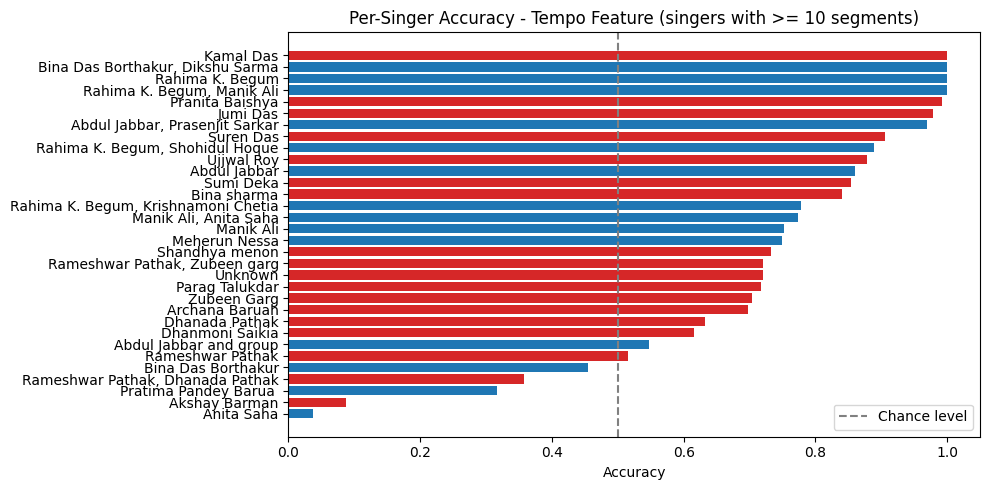

In [6]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 5))
colors = ["#d62728" if g == "Kamrupi" else "#1f77b4" for g in reliable.sort_values("accuracy")["genre"]]
ax.barh(reliable.sort_values("accuracy")["singer"], reliable.sort_values("accuracy")["accuracy"], color=colors)
ax.axvline(0.5, color="gray", linestyle="--", label="Chance level")
ax.set_xlabel("Accuracy")
ax.set_title("Per-Singer Accuracy - Tempo Feature (singers with >= {} segments)".format(MIN_SEGMENTS))
ax.legend()
plt.tight_layout()
plt.savefig("results/per_singer_tempo.png", dpi=150)
plt.show()